# Ollama Performance Analysis

Load-test results from `perf/load_test.py` — 256 streaming requests across
a 32-cell configuration matrix:

| Dimension | Values |
|---|---|
| Prompt length | **short** (~10 tok) vs **long** (~50-100 tok) |
| Concurrency | 1, 2, 4, 8 |
| Cache mode | **cold** (unique prompts) vs **warm** (same prompt repeated) |
| Stop sequence | **none** vs **newline** (`\n`) |

Per-request metrics: **TTFT** (time-to-first-token via streaming),
**total latency**, **tokens/second**, prompt + generated token counts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

BLUE, RED, GREEN, ORANGE = "#2563eb", "#dc2626", "#16a34a", "#ea580c"

df = pd.read_csv(Path("metrics.csv"))
print(f"{len(df)} rows  |  {df.groupby(['prompt_type','concurrency','cache_mode','stop_seq']).ngroups} configs")
df.describe().round(1)

256 rows  |  32 configs


,concurrency,request_id,prompt_tokens,tokens_generated,ttft_ms,total_latency_ms,tokens_per_second
count,256.0,256.0,256.0,256.0,256.0,256.0,256.0
mean,3.8,3.5,34.7,52.5,2197.0,3293.0,51.3
std,2.7,2.3,17.7,47.2,3701.3,4309.6,5.1
min,1.0,0.0,15.0,3.0,87.6,207.7,32.0
25%,1.8,1.8,17.0,12.0,243.0,665.2,48.9
50%,3.0,3.5,35.0,39.0,783.9,1613.6,51.1
75%,5.0,5.2,52.0,82.2,2591.7,3779.4,52.9
max,8.0,7.0,58.0,128.0,24179.2,26941.2,77.2


## 1 — Cold-Start Artifact

The very first request of the test suite hits Ollama's one-time model-load
path (GPU warmup / weight loading). We identify it, note the cost, and
exclude it from subsequent analysis so it doesn't skew percentiles.

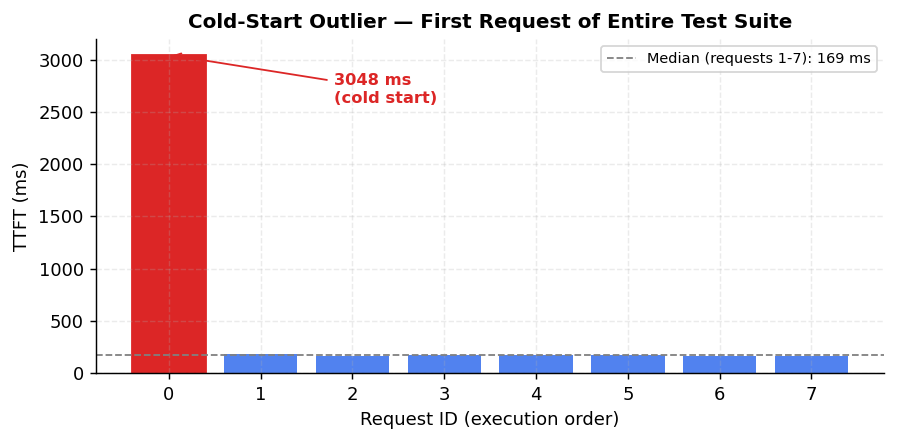

Excluded 1 cold-start row → 255 rows for analysis


In [2]:
first_cfg = df[(df.prompt_type == "short") & (df.concurrency == 1)
               & (df.cache_mode == "cold") & (df.stop_seq == "none")]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(first_cfg.request_id, first_cfg.ttft_ms, color=BLUE, alpha=0.8)
bars[0].set_color(RED)
bars[0].set_alpha(1.0)
median_rest = first_cfg.ttft_ms.iloc[1:].median()
ax.axhline(median_rest, ls="--", color="grey", lw=1,
           label=f"Median (requests 1-7): {median_rest:.0f} ms")
ax.annotate(f"{first_cfg.ttft_ms.iloc[0]:.0f} ms\n(cold start)",
            xy=(0, first_cfg.ttft_ms.iloc[0]),
            xytext=(1.8, first_cfg.ttft_ms.iloc[0] * 0.85),
            arrowprops=dict(arrowstyle="->", color=RED),
            fontsize=9, color=RED, fontweight="bold")
ax.set_xlabel("Request ID (execution order)")
ax.set_ylabel("TTFT (ms)")
ax.set_title("Cold-Start Outlier — First Request of Entire Test Suite", fontweight="bold")
ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig("cold_start.png", bbox_inches="tight")
plt.show()

cold_start_mask = (
    (df.prompt_type == "short") & (df.concurrency == 1)
    & (df.cache_mode == "cold") & (df.stop_seq == "none")
    & (df.request_id == 0)
)
df_clean = df[~cold_start_mask].copy()
print(f"Excluded 1 cold-start row → {len(df_clean)} rows for analysis")

## 2 — Latency Distributions

Box plots show the full distribution shape — median, quartiles, outliers —
rather than reducing everything to summary statistics. Ollama serializes
inference, so each additional concurrent client adds queue wait.

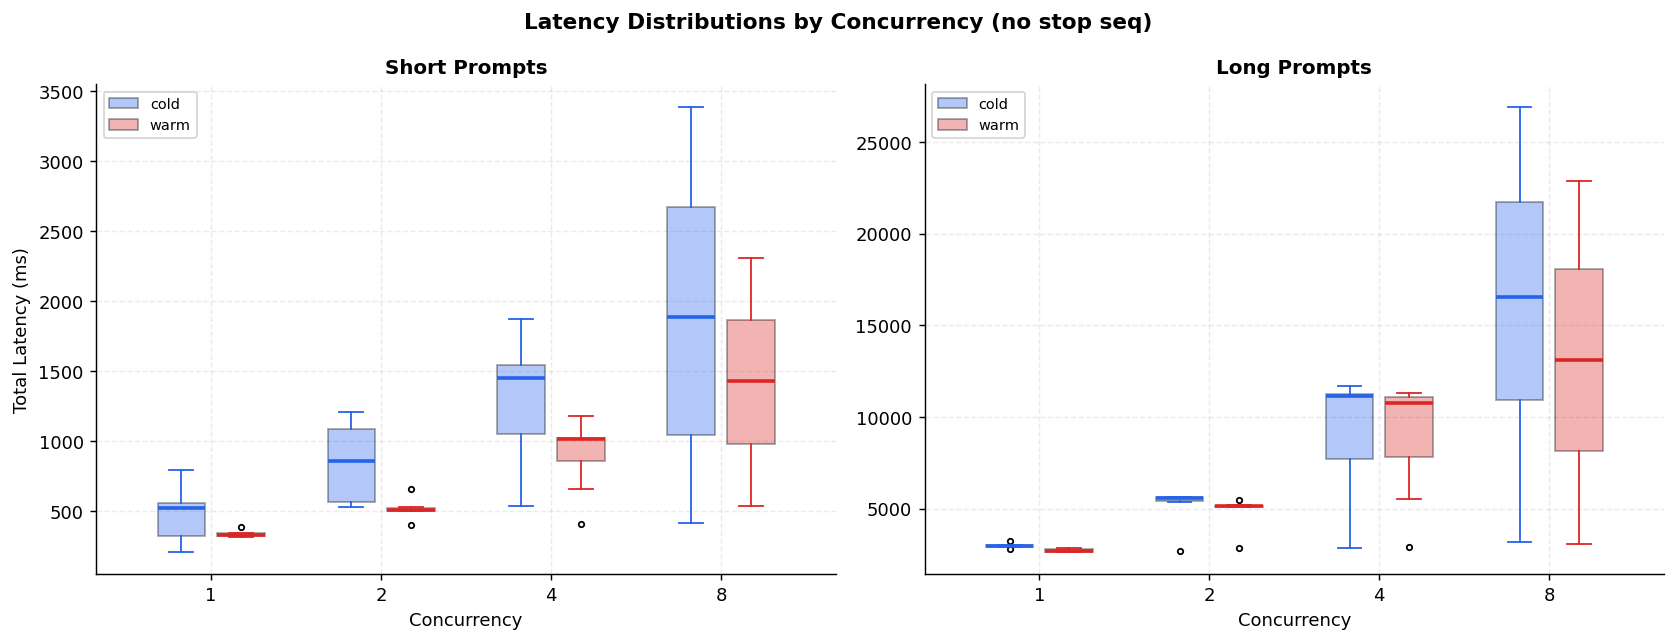

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, pt in zip(axes, ["short", "long"]):
    sub = df_clean[(df_clean.prompt_type == pt) & (df_clean.stop_seq == "none")]
    data_cold, data_warm = [], []
    concs = sorted(sub.concurrency.unique())

    for c in concs:
        data_cold.append(sub[(sub.concurrency == c) & (sub.cache_mode == "cold")].total_latency_ms.values)
        data_warm.append(sub[(sub.concurrency == c) & (sub.cache_mode == "warm")].total_latency_ms.values)

    x = np.arange(len(concs))
    w = 0.35
    bp1 = ax.boxplot(data_cold, positions=x - w/2, widths=w * 0.8,
                     patch_artist=True, flierprops=dict(markersize=3))
    bp2 = ax.boxplot(data_warm, positions=x + w/2, widths=w * 0.8,
                     patch_artist=True, flierprops=dict(markersize=3))
    for bp, color in [(bp1, BLUE), (bp2, RED)]:
        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.35)
        for el in ["whiskers", "caps"]:
            for line in bp[el]:
                line.set_color(color)
        for line in bp["medians"]:
            line.set_color(color)
            line.set_linewidth(2)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in concs])
    ax.set_xlabel("Concurrency")
    ax.set_title(f"{pt.title()} Prompts", fontweight="bold")
    if pt == "short":
        ax.set_ylabel("Total Latency (ms)")
    ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ["cold", "warm"],
              fontsize=8, loc="upper left")

fig.suptitle("Latency Distributions by Concurrency (no stop seq)",
             fontweight="bold", fontsize=12)
fig.tight_layout()
plt.savefig("latency_distributions.png", bbox_inches="tight")
plt.show()

## 3 — Cache Effect

When the same prompt is repeated (warm), Ollama reuses its KV cache,
skipping prompt evaluation. The benefit is most visible at c=1 (no
queueing noise) and fades under load as queue wait dominates.

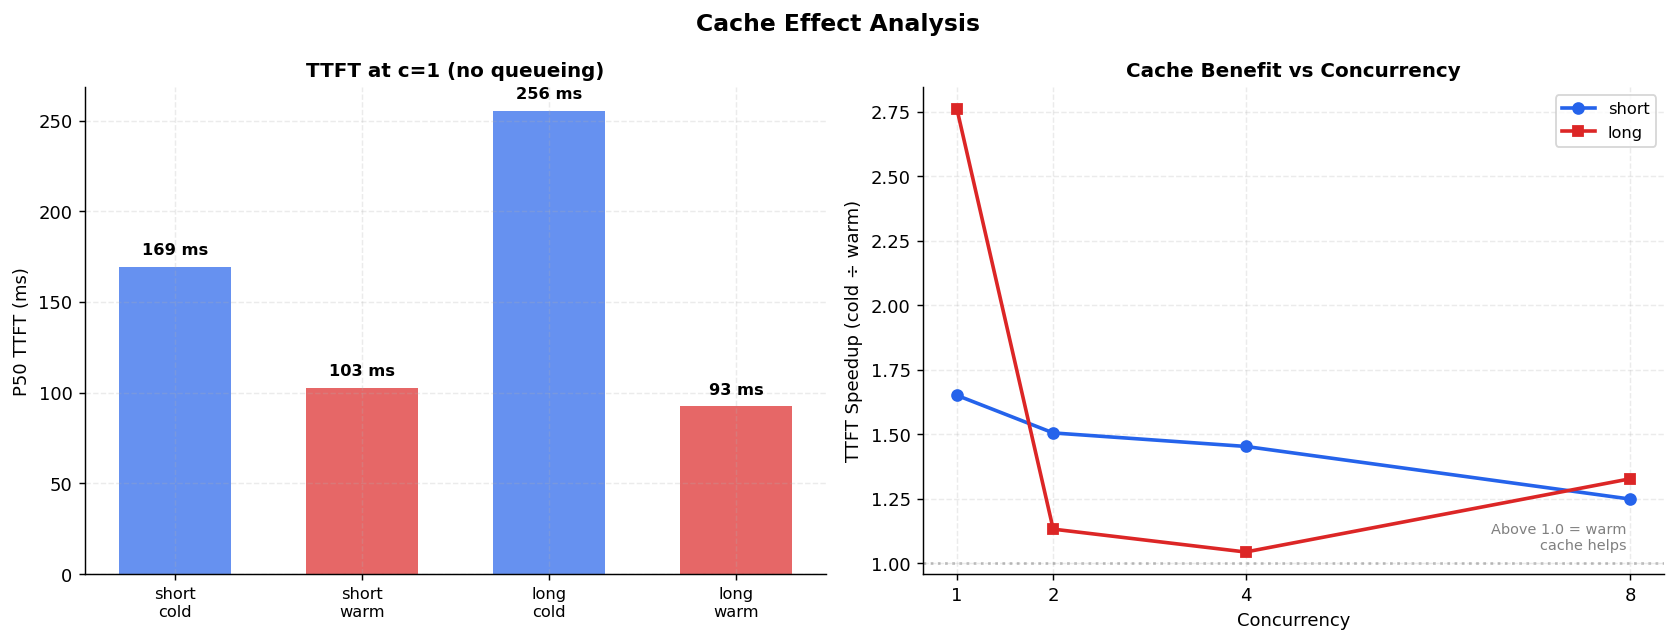

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel A: TTFT bar chart at c=1 ---
c1 = df_clean[(df_clean.concurrency == 1) & (df_clean.stop_seq == "none")]
bar_data = []
for pt in ["short", "long"]:
    for cm in ["cold", "warm"]:
        med = c1[(c1.prompt_type == pt) & (c1.cache_mode == cm)].ttft_ms.median()
        bar_data.append((f"{pt}\n{cm}", med, BLUE if cm == "cold" else RED))

x_pos = np.arange(len(bar_data))
bars = ax1.bar(x_pos, [d[1] for d in bar_data],
               color=[d[2] for d in bar_data], alpha=0.7, width=0.6)
for bar, (_, val, _) in zip(bars, bar_data):
    ax1.text(bar.get_x() + bar.get_width() / 2, val + 5,
             f"{val:.0f} ms", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.set_xticks(x_pos)
ax1.set_xticklabels([d[0] for d in bar_data], fontsize=9)
ax1.set_ylabel("P50 TTFT (ms)")
ax1.set_title("TTFT at c=1 (no queueing)", fontweight="bold")

# --- Panel B: Speedup ratio across concurrency ---
concs = sorted(df_clean.concurrency.unique())
for pt, color, marker in [("short", BLUE, "o"), ("long", RED, "s")]:
    speedups = []
    for c in concs:
        sub = df_clean[(df_clean.prompt_type == pt) & (df_clean.concurrency == c)
                       & (df_clean.stop_seq == "none")]
        cold_med = sub[sub.cache_mode == "cold"].ttft_ms.median()
        warm_med = sub[sub.cache_mode == "warm"].ttft_ms.median()
        speedups.append(cold_med / warm_med if warm_med > 0 else 1.0)
    ax2.plot(concs, speedups, f"-{marker}", color=color,
             label=f"{pt}", markersize=6, lw=2)

ax2.axhline(1.0, ls=":", color="grey", alpha=0.5)
ax2.set_xlabel("Concurrency")
ax2.set_ylabel("TTFT Speedup (cold ÷ warm)")
ax2.set_xticks([1, 2, 4, 8])
ax2.set_title("Cache Benefit vs Concurrency", fontweight="bold")
ax2.legend(fontsize=9)
ax2.annotate("Above 1.0 = warm\ncache helps", xy=(0.95, 0.05),
             xycoords="axes fraction", fontsize=8, color="grey",
             ha="right")

fig.suptitle("Cache Effect Analysis", fontweight="bold", fontsize=13)
fig.tight_layout()
plt.savefig("cache_effect.png", bbox_inches="tight")
plt.show()

## 4 — Per-Request Generation Speed

Tokens/sec is compute-bound and should be independent of concurrency.
Individual data points (jittered) are overlaid on the median trend
to show actual variance.

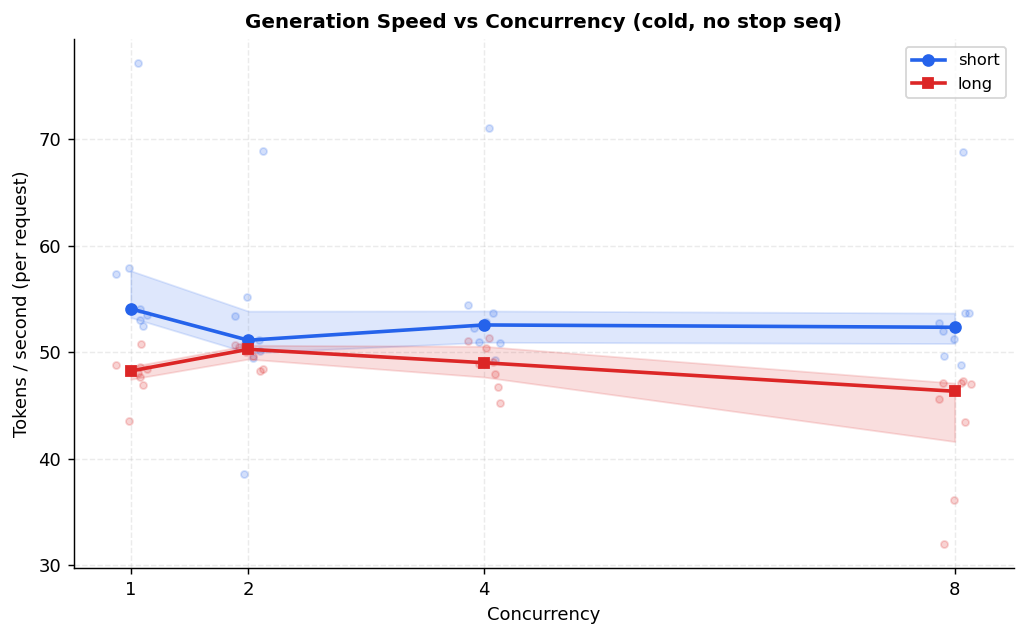

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

for pt, color, marker in [("short", BLUE, "o"), ("long", RED, "s")]:
    sub = df_clean[(df_clean.prompt_type == pt) & (df_clean.stop_seq == "none")
                   & (df_clean.cache_mode == "cold")]
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(sub))
    ax.scatter(sub.concurrency + jitter, sub.tokens_per_second,
              color=color, alpha=0.2, s=15, zorder=1)
    g = sub.groupby("concurrency")["tokens_per_second"]
    med = g.median()
    lo, hi = g.quantile(0.25), g.quantile(0.75)
    ax.plot(med.index, med, f"-{marker}", color=color, label=f"{pt}",
            zorder=3, markersize=6, lw=2)
    ax.fill_between(med.index, lo, hi, alpha=0.15, color=color, zorder=2)

ax.set_xlabel("Concurrency")
ax.set_ylabel("Tokens / second (per request)")
ax.set_xticks([1, 2, 4, 8])
ax.legend(fontsize=9)
ax.set_title("Generation Speed vs Concurrency (cold, no stop seq)",
             fontweight="bold")
fig.tight_layout()
plt.savefig("tps_vs_concurrency.png", bbox_inches="tight")
plt.show()

## 5 — Stop-Sequence Impact

A `\n` stop sequence causes early termination. The effect is meaningful
only for long prompts where `max_tokens=128` would otherwise be hit.
Short prompts already generate few tokens, so stop sequences provide
no benefit there (omitted).

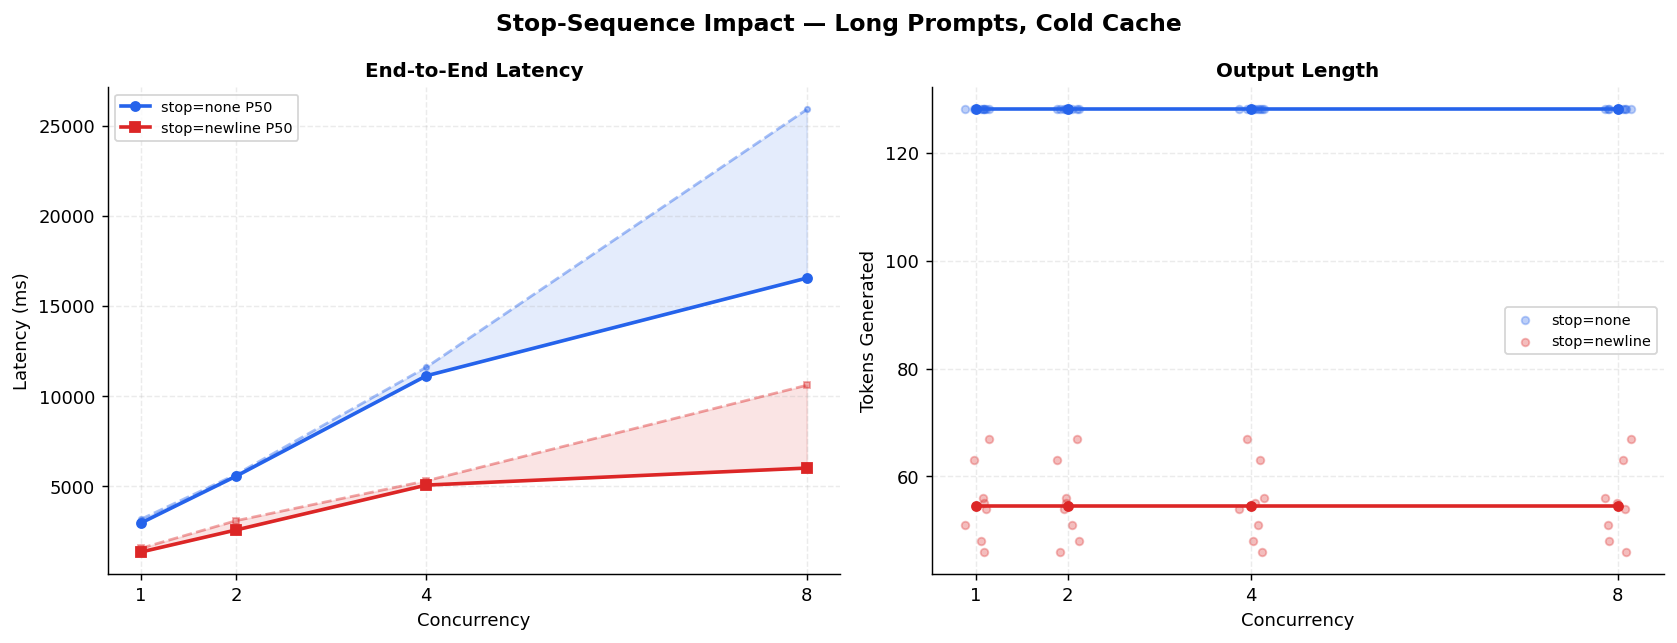

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
sub = df_clean[(df_clean.prompt_type == "long") & (df_clean.cache_mode == "cold")]

# Left: latency
for ss, color, marker in [("none", BLUE, "o"), ("newline", RED, "s")]:
    g = sub[sub.stop_seq == ss].groupby("concurrency")["total_latency_ms"]
    p50, p95 = g.median(), g.quantile(0.95)
    ax1.plot(p50.index, p50, f"-{marker}", color=color,
             label=f"stop={ss} P50", markersize=5, lw=2)
    ax1.fill_between(p50.index, p50, p95, alpha=0.12, color=color)
    ax1.plot(p95.index, p95, f"--{marker}", color=color, alpha=0.4, markersize=3)
ax1.set_xlabel("Concurrency")
ax1.set_ylabel("Latency (ms)")
ax1.set_xticks([1, 2, 4, 8])
ax1.set_title("End-to-End Latency", fontweight="bold")
ax1.legend(fontsize=8)

# Right: tokens generated (scatter + median)
for ss, color in [("none", BLUE), ("newline", RED)]:
    s = sub[sub.stop_seq == ss]
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(s))
    ax2.scatter(s.concurrency + jitter, s.tokens_generated,
               color=color, alpha=0.3, s=18, label=f"stop={ss}")
    g = s.groupby("concurrency")["tokens_generated"].median()
    ax2.plot(g.index, g, "-o", color=color, markersize=5, lw=2)
ax2.set_xlabel("Concurrency")
ax2.set_ylabel("Tokens Generated")
ax2.set_xticks([1, 2, 4, 8])
ax2.set_title("Output Length", fontweight="bold")
ax2.legend(fontsize=8)

fig.suptitle("Stop-Sequence Impact — Long Prompts, Cold Cache",
             fontweight="bold", fontsize=13)
fig.tight_layout()
plt.savefig("stop_seq_impact.png", bbox_inches="tight")
plt.show()

## 6 — Aggregate Throughput

By Little's law, effective throughput = *concurrency ÷ mean response time*.
For a single-model local endpoint the server is the bottleneck: aggregate
throughput should plateau once saturated (c ≥ 2), proving that adding
more clients only increases per-request latency without increasing
total output.

Note: *per-request* generation speed (Section 4) is also flat — the model
generates at the same tok/s regardless of queue depth. These two facts
together confirm the system is purely queue-bound under concurrency, not
compute-degraded.

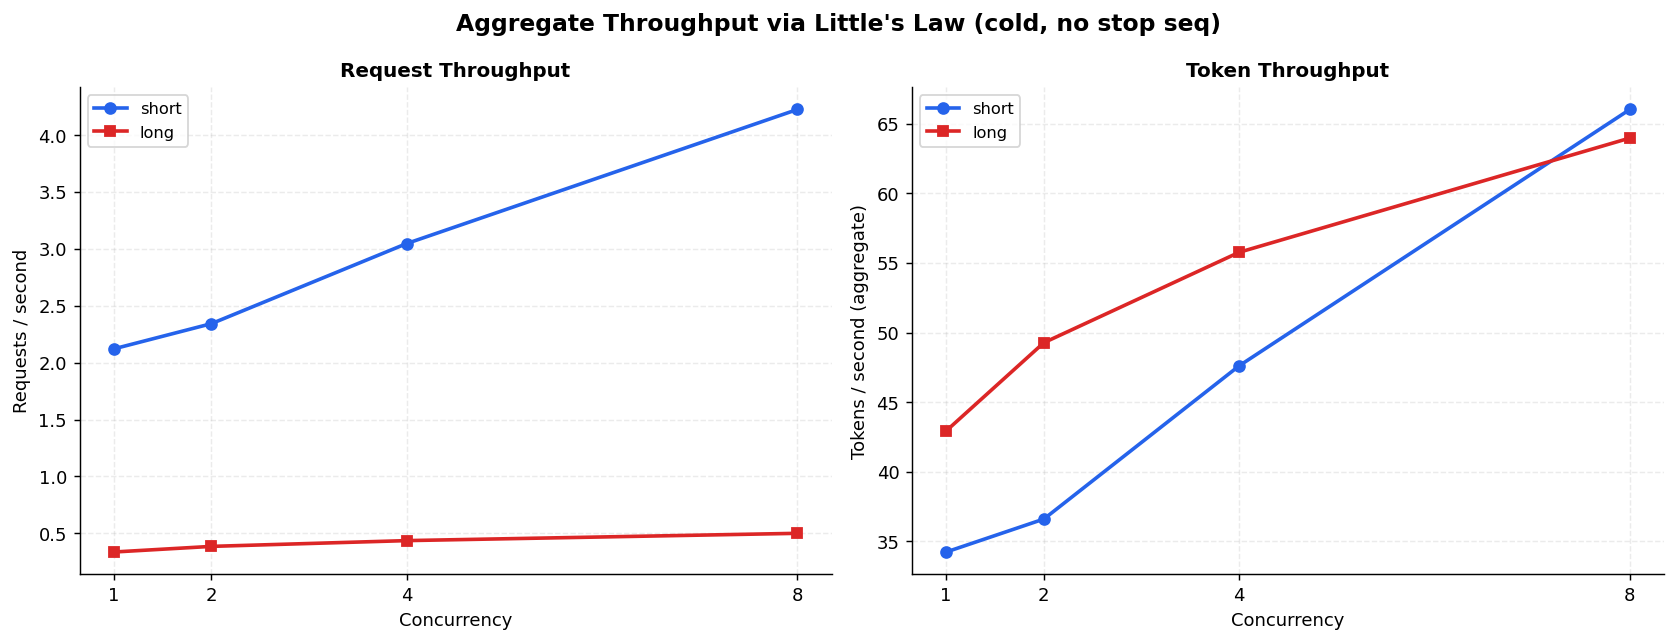

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for pt, color, marker in [("short", BLUE, "o"), ("long", RED, "s")]:
    sub = df_clean[(df_clean.prompt_type == pt) & (df_clean.stop_seq == "none")
                   & (df_clean.cache_mode == "cold")]
    rps_list, tps_list = [], []
    concs = sorted(sub.concurrency.unique())
    for c in concs:
        grp = sub[sub.concurrency == c]
        mean_lat = grp.total_latency_ms.mean()
        mean_tok = grp.tokens_generated.mean()
        rps_list.append(c / (mean_lat / 1000))
        tps_list.append(c * mean_tok / (mean_lat / 1000))
    ax1.plot(concs, rps_list, f"-{marker}", color=color,
             label=f"{pt}", markersize=6, lw=2)
    ax2.plot(concs, tps_list, f"-{marker}", color=color,
             label=f"{pt}", markersize=6, lw=2)

for ax, ylabel, title in [
    (ax1, "Requests / second", "Request Throughput"),
    (ax2, "Tokens / second (aggregate)", "Token Throughput"),
]:
    ax.set_xlabel("Concurrency")
    ax.set_ylabel(ylabel)
    ax.set_xticks([1, 2, 4, 8])
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9)

fig.suptitle("Aggregate Throughput via Little's Law (cold, no stop seq)",
             fontweight="bold", fontsize=13)
fig.tight_layout()
plt.savefig("throughput.png", bbox_inches="tight")
plt.show()

## 7 — Configuration Heatmap

A single-glance overview of P50 latency across all 32 configurations.
Rows are configs, columns are concurrency levels, cell values are
milliseconds. The gradient immediately reveals which settings dominate.

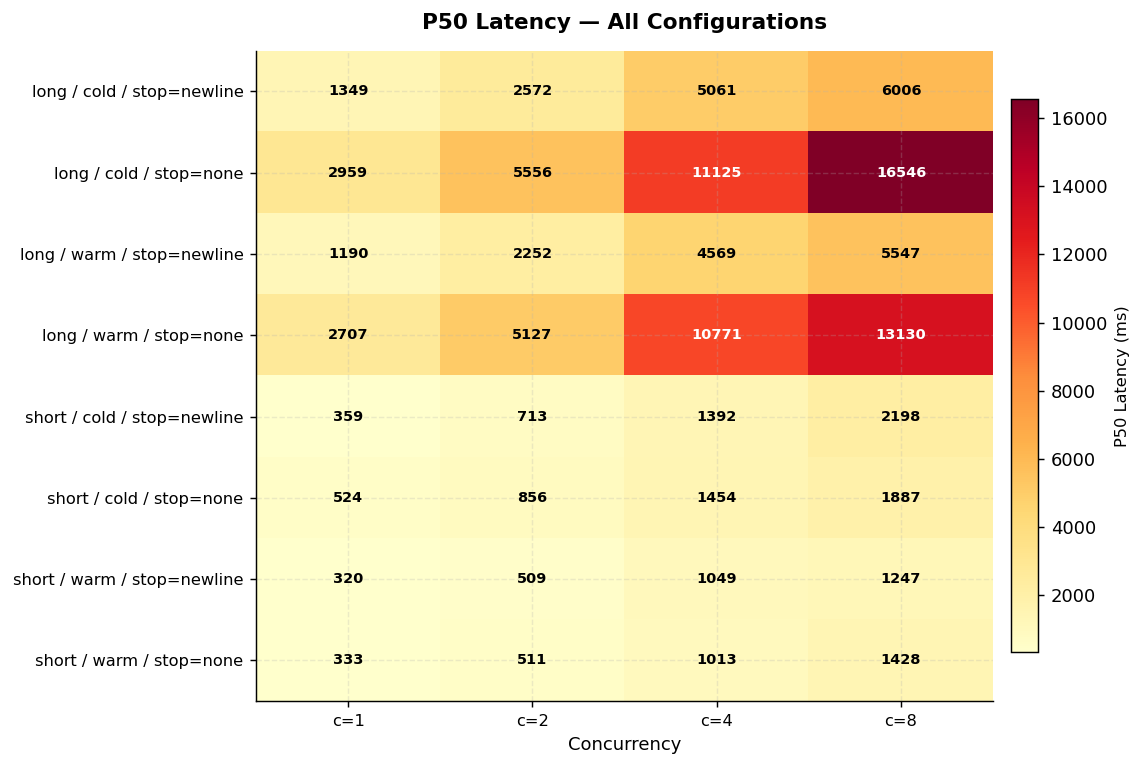

In [8]:
pivot = (
    df_clean.groupby(["prompt_type", "cache_mode", "stop_seq", "concurrency"])
    ["total_latency_ms"].median()
    .reset_index()
)
pivot["config"] = pivot.apply(
    lambda r: f"{r.prompt_type} / {r.cache_mode} / stop={r.stop_seq}", axis=1
)
hm = pivot.pivot(index="config", columns="concurrency", values="total_latency_ms")
hm = hm.sort_index()

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(hm.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(hm.columns)))
ax.set_xticklabels([f"c={c}" for c in hm.columns], fontsize=9)
ax.set_yticks(range(len(hm.index)))
ax.set_yticklabels(hm.index, fontsize=9)
ax.set_xlabel("Concurrency")

for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        val = hm.values[i, j]
        text_color = "white" if val > hm.values.max() * 0.55 else "black"
        ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                fontsize=8, fontweight="bold", color=text_color)

cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label("P50 Latency (ms)", fontsize=9)
ax.set_title("P50 Latency — All Configurations",
             fontweight="bold", fontsize=12, pad=12)
fig.tight_layout()
plt.savefig("heatmap.png", bbox_inches="tight")
plt.show()

## Summary Table

In [9]:
agg = (
    df_clean.groupby(["prompt_type", "concurrency", "cache_mode", "stop_seq"])
    .agg(
        n=("total_latency_ms", "count"),
        P50_lat=("total_latency_ms", "median"),
        P95_lat=("total_latency_ms", lambda x: np.percentile(x, 95)),
        P99_lat=("total_latency_ms", lambda x: np.percentile(x, 99)),
        P50_ttft=("ttft_ms", "median"),
        avg_tps=("tokens_per_second", "mean"),
        avg_tokens=("tokens_generated", "mean"),
    )
    .round(1)
)
print(f"Aggregate stats — {len(df_clean)} requests (1 cold-start excluded)")
agg

Aggregate stats — 255 requests (1 cold-start excluded)


n  P50_lat  P95_lat  P99_lat  \
prompt_type concurrency cache_mode stop_seq                                 
long        1           cold       newline   8   1349.4   1558.6   1587.3   
                                   none      8   2959.3   3171.8   3232.2   
                        warm       newline   8   1190.1   1285.5   1286.9   
                                   none      8   2706.9   2827.4   2835.6   
            2           cold       newline   8   2572.1   3088.2   3185.8   
                                   none      8   5556.0   5653.2   5653.9   
                        warm       newline   8   2252.0   2432.2   2467.2   
                                   none      8   5127.2   5389.9   5476.8   
            4           cold       newline   8   5061.4   5299.4   5349.1   
                                   none      8  11125.1  11600.7  11674.8   
                        warm       newline   8   4569.2   4860.9   4883.1   
                                   none      8  10770.8  11268.9  11312.5   
            8           cold       newline   8   6006.0  10602.7  11057.8   
                                   none      8  16546.1  25900.9  26733.1   
                        warm       newline   8   5547.1   9271.4   9594.9   
                                   none      8  13129.8  21949.7  22695.6   
short       1           cold       newline   8    359.3    703.6    758.4   
                                   none      7    524.3    730.8    782.8   
                        warm       newline   8    319.7    326.7    327.9   
                                   none      8    333.1    372.0    383.2   
            2           cold       newline   8    712.6   1024.4   1035.1   
                                   none      8    855.6   1210.3   1211.6   
                        warm       newline   8    509.4    558.9    579.7   
                                   none      8    511.1    613.0    649.4   
            4           cold       newline   8   1392.3   1672.6   1703.5   
                                   none      8   1454.0   1822.4   1861.4   
                        warm       newline   8   1048.9   1087.1   1093.9   
                                   none      8   1013.4   1123.7   1166.3   
            8           cold       newline   8   2198.5   3074.9   3114.4   
                                   none      8   1886.5   3340.0   3379.9   
                        warm       newline   8   1247.3   2039.6   2110.1   
                                   none      8   1427.8   2220.6   2290.1   

                                             P50_ttft  avg_tps  avg_tokens  
prompt_type concurrency cache_mode stop_seq                                 
long        1           cold       newline      246.2     49.3        55.0  
                                   none         255.5     47.9       128.0  
                        warm       newline       93.2     50.0        55.0  
                                   none          92.6     49.8       128.0  
            2           cold       newline     1469.2     49.2        55.0  
                                   none        2925.9     49.9       128.0  
                        warm       newline     1148.8     50.1        55.0  
                                   none        2582.5     50.8       128.0  
            4           cold       newline     4063.2     51.4        55.0  
                                   none        8497.8     48.9       128.0  
                        warm       newline     3432.9     48.9        55.0  
                                   none        8137.0     48.1       128.0  
            8           cold       newline     4892.8     47.8        55.0  
                                   none       13717.0     43.2       128.0  
                        warm       newline     4363.1     47.4        55.0  
                                   none       10327.6     46.4       128.0  
short       1           cold       newli

## Commentary

### Data Quality

Request #0 exhibits a **3048 ms TTFT** (17× the steady-state median of
170 ms) due to Ollama's one-time model-load cost. It is excluded from
all analysis. In production this maps to a cold-start concern; the
`serve.py` startup script absorbs it before benchmarks begin.

### Key Findings

1. **Latency scales linearly with concurrency — system is queue-bound.**
   Ollama serializes inference, so concurrent requests queue. The box plots
   (Section 2) and heatmap (Section 7) both confirm P50 roughly doubles per
   concurrency doubling. Crucially, the scaling is *slightly sublinear* at
   c=8: long/cold/none shows 5.6× at c=8 vs the 8× that pure linear
   scaling would predict. This is because our batch size equals concurrency
   (8 requests at c=8 = one wave, no second-wave queueing). With a deeper
   request queue the scaling would approach linear. Combined with the flat
   per-request tok/s (Section 4), this confirms the system is purely
   queue-bound — concurrency adds wait time without degrading compute.

2. **Aggregate throughput is flat.** Section 6 confirms that requests/sec and
   tokens/sec are approximately constant regardless of concurrency — the
   server's sequential processing is the bottleneck. Adding clients increases
   latency without improving total output (M/D/1 queue at saturation).

3. **Per-request tok/s is stable (~48–58 tok/s).** Generation speed is
   compute-bound (Section 4). Short prompts are slightly faster due to less
   KV-cache overhead per generated token. This stability under load confirms
   there is no resource contention degrading the model's inference path.

4. **Warm cache cuts TTFT 2–3× at low concurrency.** At c=1, long-prompt
   warm TTFT is 93 ms vs cold's 256 ms (Section 3). The speedup ratio
   decays toward 1.0 under load as queueing wait dominates prompt
   evaluation time.

5. **Stop sequences are the strongest latency lever.** For long prompts,
   adding `\n` stop cuts P50 from ~3.0s to ~1.3s at c=1 (Section 5)
   because generation terminates at ~54 tokens instead of hitting the
   128-token cap.

### Implications for the Evaluation Pipeline

- **Run benchmarks at c=1** for lowest per-request latency — concurrency
  buys no throughput gain against a single-model Ollama endpoint.
- **Use stop sequences** in custom tasks (`code_output` uses `\n`).
- **Prompt caching** provides 2–3× TTFT speedup for repeated prompts —
  directly relevant to lm-eval's multiple-choice scoring where all
  options share the same context prefix.
- **Cold starts** are a one-time cost (~3s); subsequent requests are fast.